# Sim-to-real SAC and TD3 benchmark on TraceWin

This report compares the best checkpoints obtained after sim-to-real fine-tuning of SAC and TD3.
Both policies started from dataset-042 training with a 20-step horizon and 300,000 surrogate steps,
followed by 10,000 TraceWin fine-tuning steps. They are evaluated together on real TraceWin workspace 2
over 20 matched-reset episodes with a maximum of 20 steps, matching the training horizon.

It contains only the artifacts needed for the final decision:

- provenance of the two sim-to-real checkpoints;
- the exact bar and box plots from this 20-step benchmark;
- a matched-reset comparison of SAC and TD3;
- comparison with warm-started Bayesian Optimization;
- operational timing at the end.

No training or TraceWin simulation is launched here. The notebook reads the saved
artifacts and renders a concise, reproducible summary.

In [1]:
from datetime import datetime
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def find_repository_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "beam_optimization" / "config" / "adige.py").is_file():
            return candidate
    raise FileNotFoundError("Repository root not found")


REPO_ROOT = find_repository_root()
RESULTS_DIR = REPO_ROOT / "beam_optimization" / "results"
SAC_TRAIN_DIR = RESULTS_DIR / "train" / "rl" / "sim2real_sac_042_1_workspace2_h20_10kreal"
TD3_TRAIN_DIR = RESULTS_DIR / "train" / "rl" / "sim2real_td3_042_1_workspace3_h20_10kreal"
BENCHMARK_DIR = RESULTS_DIR / "benchmark"
BENCHMARK_EVAL_DIR = BENCHMARK_DIR / "sim2real_sac_td3_042_1_workspace2_20steps"
BENCHMARK_EVAL_PATH = BENCHMARK_EVAL_DIR / "sim2real_sac_td3_042_1_workspace2_20steps_tracewin.json"
BENCHMARK_EPISODES_PATH = BENCHMARK_EVAL_DIR / "benchmark_policy_episodes_tracewin.csv"
BENCHMARK_SUMMARY_PATH = BENCHMARK_EVAL_DIR / "benchmark_policy_summary_tracewin.csv"
BAYESIAN_DIR = RESULTS_DIR / "bayesian_opt" / "warm_start_workspace1_5x300"
for required in (SAC_TRAIN_DIR, TD3_TRAIN_DIR, BENCHMARK_EVAL_PATH,
                 BENCHMARK_EPISODES_PATH, BENCHMARK_SUMMARY_PATH,
                 BAYESIAN_DIR / "results.json"):
    assert required.exists(), f"Missing required artifact: {required}"

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#d9d9d9",
    "grid.alpha": 0.45,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "legend.frameon": False,
})

print("SAC training :", SAC_TRAIN_DIR)
print("TD3 training :", TD3_TRAIN_DIR)
print("20-step data:", BENCHMARK_EVAL_PATH)
print("Episode CSV :", BENCHMARK_EPISODES_PATH)
print("Summary CSV :", BENCHMARK_SUMMARY_PATH)
print("Bayesian data:", BAYESIAN_DIR)

SAC training : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/train/rl/sim2real_sac_042_1_workspace2_h20_10kreal
TD3 training : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/train/rl/sim2real_td3_042_1_workspace3_h20_10kreal
20-step data: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/benchmark/sim2real_sac_td3_042_1_workspace2_20steps/sim2real_sac_td3_042_1_workspace2_20steps_tracewin.json
Episode CSV : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/benchmark/sim2real_sac_td3_042_1_workspace2_20steps/benchmark_policy_episodes_tracewin.csv
Summary CSV : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/benchmark/sim2real_sac_td3_042_1_workspace2_20steps/benchmark_policy_summary_tracewin.csv
Bayesian data: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/bayesian_opt/warm_start_workspace1_5x300


## 1. Sim-to-real checkpoint provenance

The compared checkpoints are the best TraceWin checkpoints saved by the two sim-to-real runs.
Each run starts from its corresponding 300,000-step dataset-042 policy and performs another
10,000 policy steps directly on TraceWin with a 20-step training horizon. SAC was fine-tuned on
workspace 2 and TD3 on workspace 3; both are evaluated below on the same workspace-2 resets.

In [2]:
training_runs = {
    "SAC sim-to-real": {
        "workspace": 2,
        "summary": SAC_TRAIN_DIR / "iterative_sim2real_sac" / "summary.json",
    },
    "TD3 sim-to-real": {
        "workspace": 3,
        "summary": TD3_TRAIN_DIR / "iterative_sim2real_td3" / "summary.json",
    },
}

training_rows = []
for algorithm, run in training_runs.items():
    summary = json.loads(run["summary"].read_text())
    training_rows.append({
        "policy": algorithm,
        "fine-tuning workspace": run["workspace"],
        "surrogate steps": 300_000,
        "TraceWin steps": 10_000,
        "training horizon": 20,
        "best TraceWin score during fine-tuning": float(summary["best_tracewin_score"]),
        "checkpoint": Path(summary["best_tracewin_policy"]).name,
    })
training_df = pd.DataFrame(training_rows).set_index("policy")
display(training_df.style.format({
    "best TraceWin score during fine-tuning": "{:.2f}",
}))

,fine-tuning workspace,surrogate steps,TraceWin steps,training horizon,best TraceWin score during fine-tuning,checkpoint
policy,,,,,,
SAC sim-to-real,2,300000,10000,20,66.58,best_tracewin_agent.zip
TD3 sim-to-real,3,300000,10000,20,64.08,best_tracewin_agent.zip


## 2. Final evaluation on real TraceWin: 20-step episodes

The promoted sim-to-real SAC and TD3 checkpoints are evaluated over 20 matched reset seeds on workspace 2. Every episode can run
for at most 20 steps and terminates earlier if the beam is lost. A failure is a final score equal to
`ERROR_SCORE = -999`. The ranking uses the final state left by the policy, not the best state visited
temporarily during its trajectory.

,episodes,score mean,score std,score median,mean npart ratio,failures,failure rate,best observed score,best observed episode,best observed step
algorithm,,,,,,,,,,
SAC sim-to-real,20,59.50,9.58,61.34,0.610,0,0%,70.15,12,12
TD3 sim-to-real,20,59.30,10.34,60.95,0.607,0,0%,70.96,2,6


**Bar plot for this exact run** — `benchmark_policy_bars_tracewin.png`

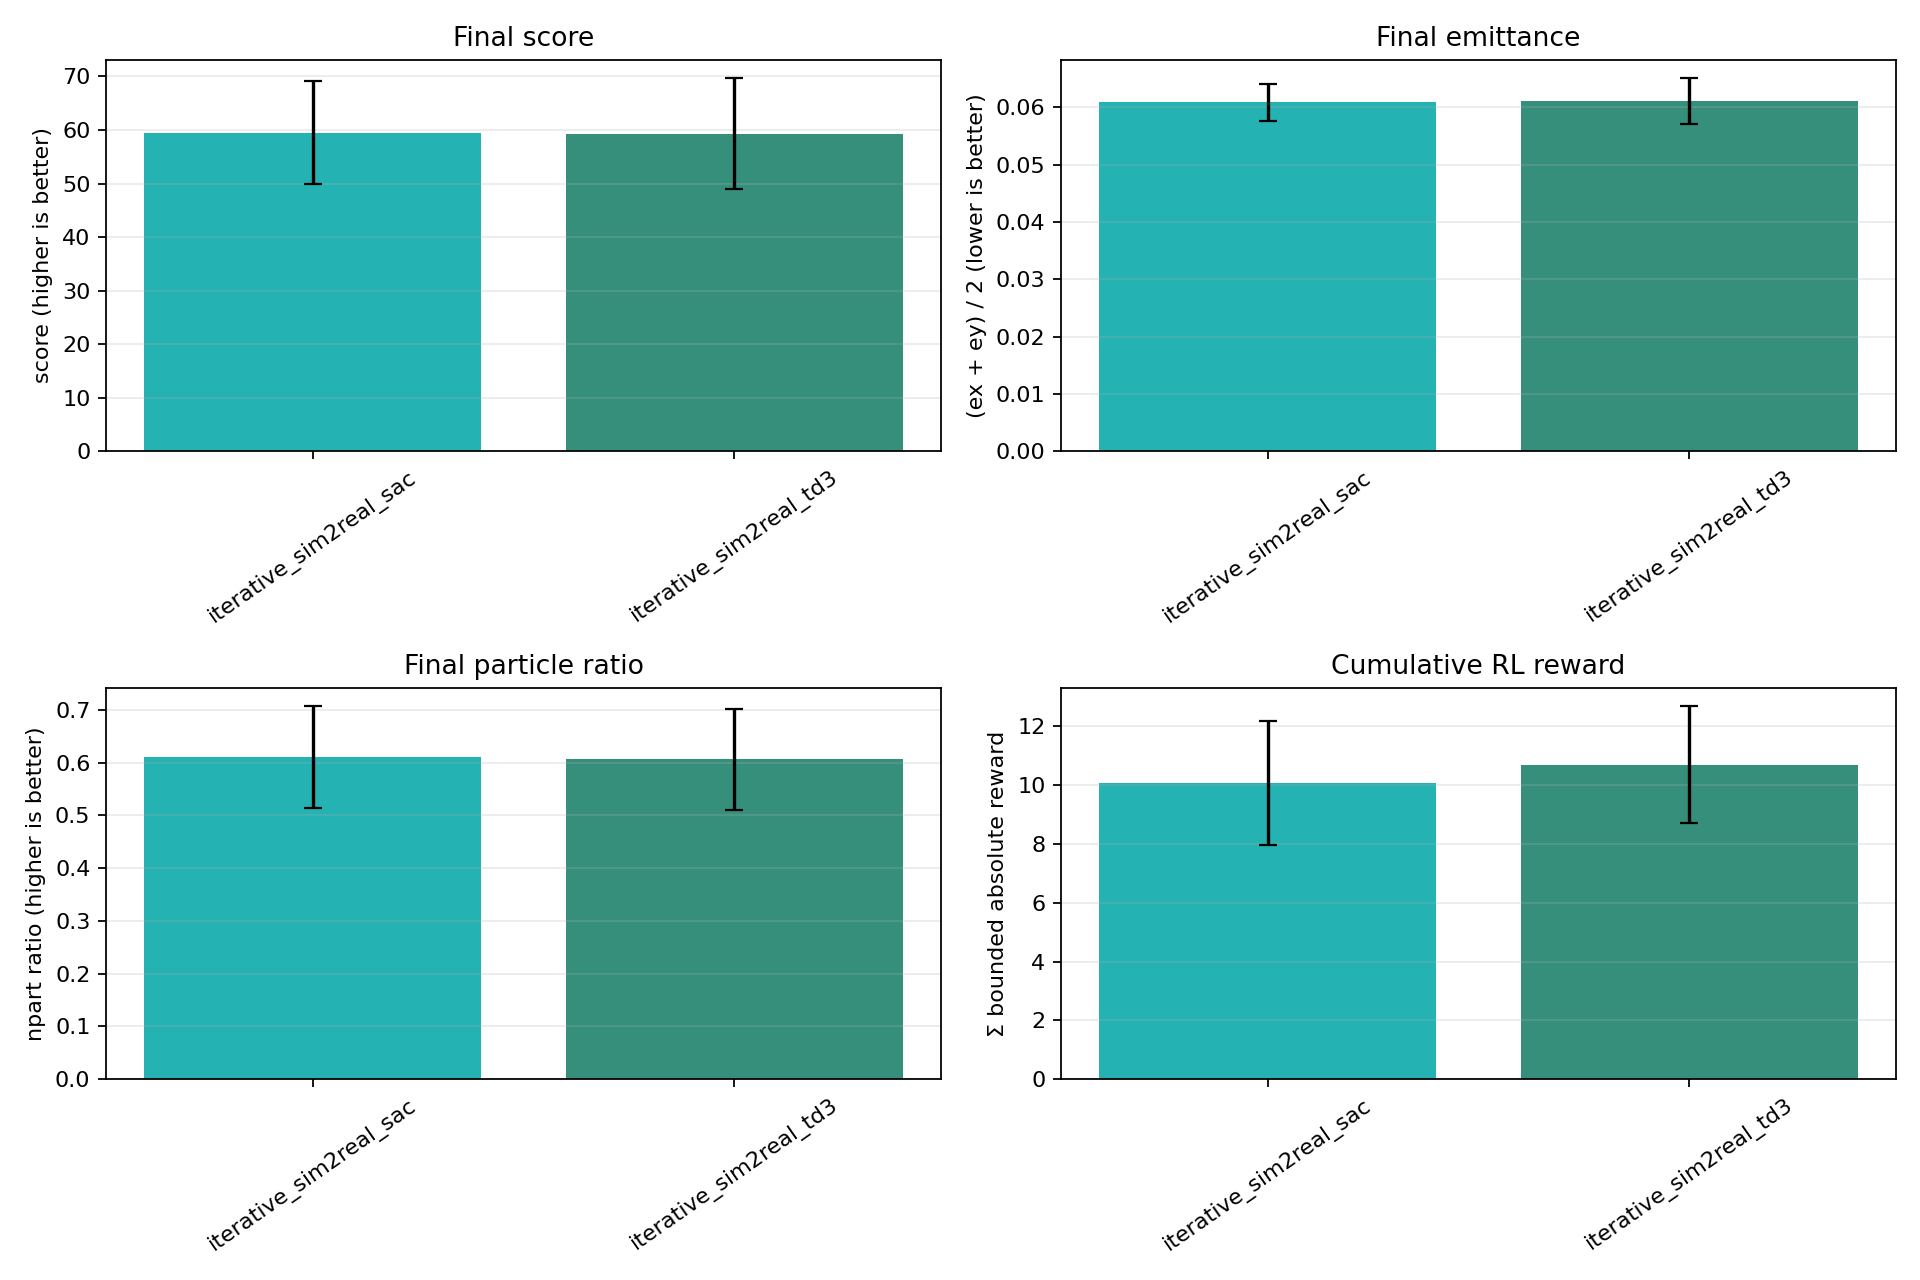

**Box plot for this exact run** — `benchmark_policy_boxplots_tracewin.png`

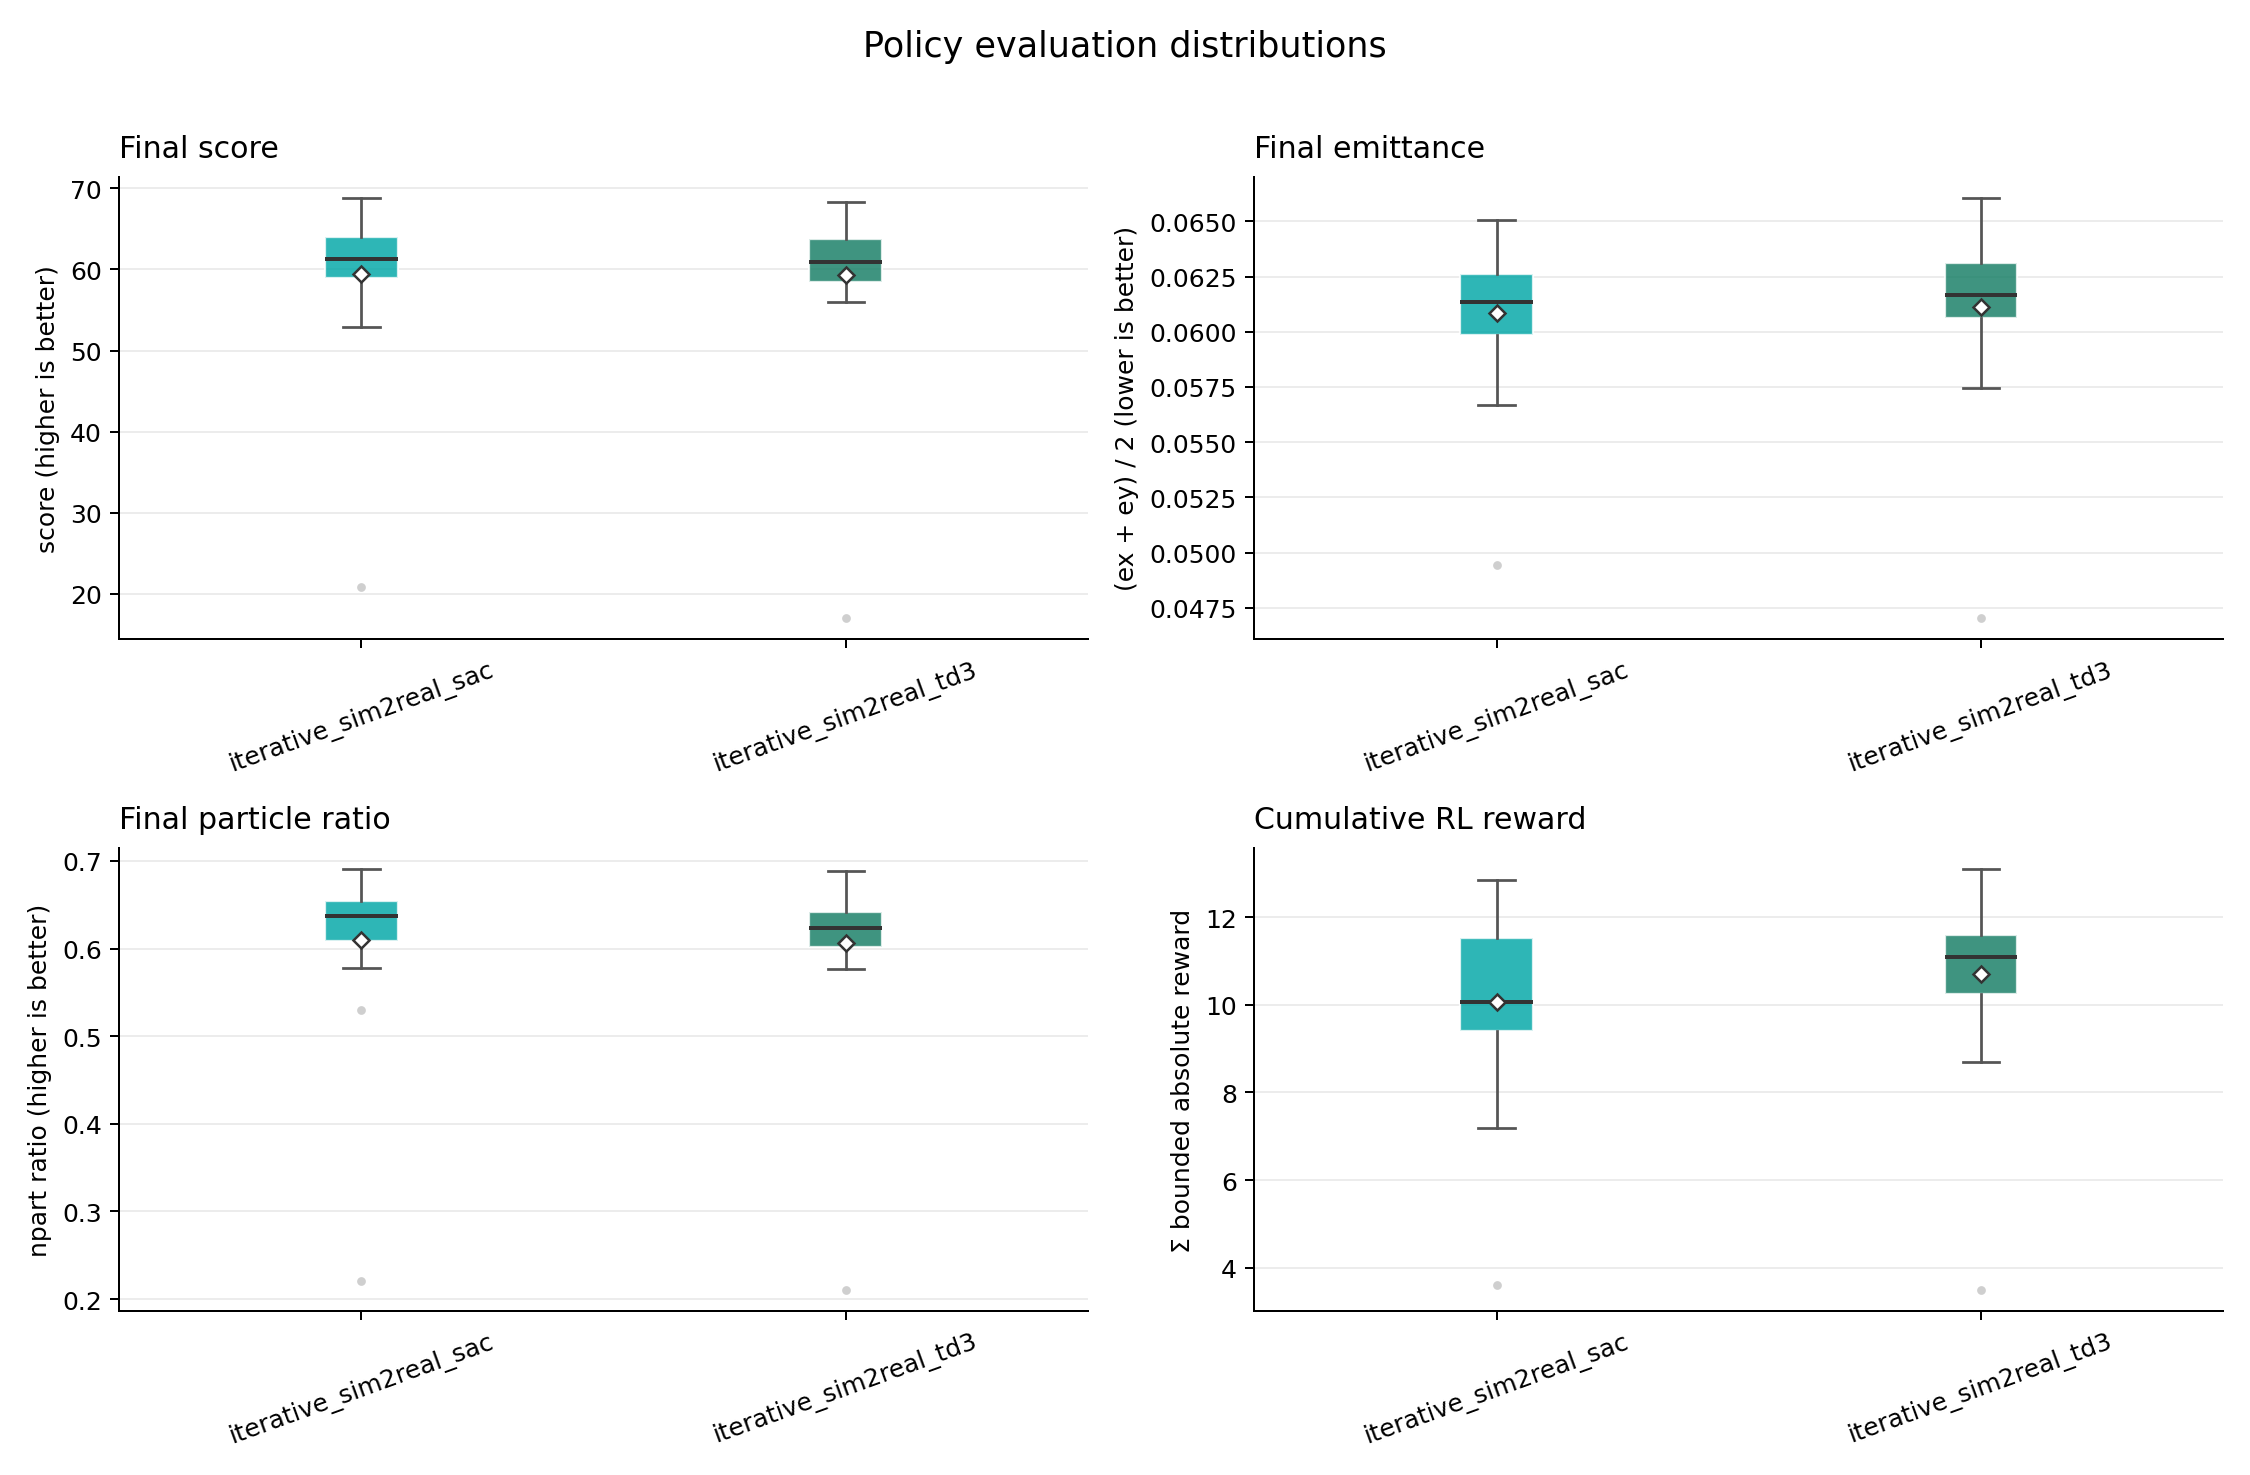

In [3]:
benchmark_eval = json.loads(BENCHMARK_EVAL_PATH.read_text())
episodes_eval = pd.read_csv(BENCHMARK_EPISODES_PATH)
reported_summary_eval = pd.read_csv(BENCHMARK_SUMMARY_PATH).set_index("algorithm")
error_score = float(benchmark_eval["score_function"]["error_score"])


def compact_summary(raw, episodes, error_score):
    failures = episodes.groupby("algorithm")["final_score"].apply(
        lambda values: int(np.isclose(values, error_score).sum())
    )
    medians = episodes.groupby("algorithm")["final_score"].median()
    result = pd.DataFrame({
        "episodes": raw["episodes"].astype(int),
        "score mean": raw["final_score_mean"],
        "score std": raw["final_score_std"],
        "score median": medians,
        "mean npart ratio": raw["final_npart_ratio_mean"],
        "failures": failures,
        "failure rate": failures / raw["episodes"],
        "best observed score": raw["best_observed_score"],
        "best observed episode": raw["best_observed_episode"].astype(int),
        "best observed step": raw["best_observed_step"].astype(int),
    })
    return result.sort_values("score mean", ascending=False)


summary_eval = compact_summary(reported_summary_eval, episodes_eval, error_score)
summary_eval.index = summary_eval.index.map({
    "iterative_sim2real_sac": "SAC sim-to-real",
    "iterative_sim2real_td3": "TD3 sim-to-real",
})
display(summary_eval.style.format({
    "score mean": "{:.2f}", "score std": "{:.2f}", "score median": "{:.2f}",
    "mean npart ratio": "{:.3f}", "failure rate": "{:.0%}",
    "best observed score": "{:.2f}", "best observed episode": "{:d}",
    "best observed step": "{:d}",
}).background_gradient(subset=["score mean"], cmap="RdYlGn"))

bar_plot_eval = BENCHMARK_EVAL_DIR / "benchmark_policy_bars_tracewin.png"
box_plot_eval = BENCHMARK_EVAL_DIR / "benchmark_policy_boxplots_tracewin.png"
display(Markdown(f"**Bar plot for this exact run** — `{bar_plot_eval.name}`"))
display(Image(filename=str(bar_plot_eval)))
display(Markdown(f"**Box plot for this exact run** — `{box_plot_eval.name}`"))
display(Image(filename=str(box_plot_eval)))

Both sim-to-real policies complete all 20 episodes without losing the beam and obtain nearly the
same final performance. SAC records **59.50 ± 9.58** with median **61.34**, while TD3 records
**59.30 ± 10.34** with median **60.95**. SAC has the higher final score in 12 of the 20
matched resets, but its mean advantage is only **0.19 points**. TD3 finds the highest individual
trajectory-wise score: **70.96** at step 6 of episode 2, whereas SAC reaches **70.15** at
step 12 of episode 12. The
`best observed` columns refer to intermediate or final configurations visited during a trajectory;
the policy ranking is instead based on the score remaining at the end of each 20-step episode.

## 3. Bayesian Optimization reference

The reference campaign contains five independent warm-started runs with 300 new real-TraceWin
evaluations each. Its best score is a selected static optimum, not a mean across reset episodes, so
it is not inserted into the policy ranking. The plots show convergence and the best configuration's
shift from the nominal machine settings.

,value
independent runs,5
new evaluations per run,300
total new evaluations,1500
successful evaluations,1492
failed evaluations,8
warm-start points reused,46
best score,60.35879
best run,5
best call in run,183


**Convergence by new TraceWin evaluations**

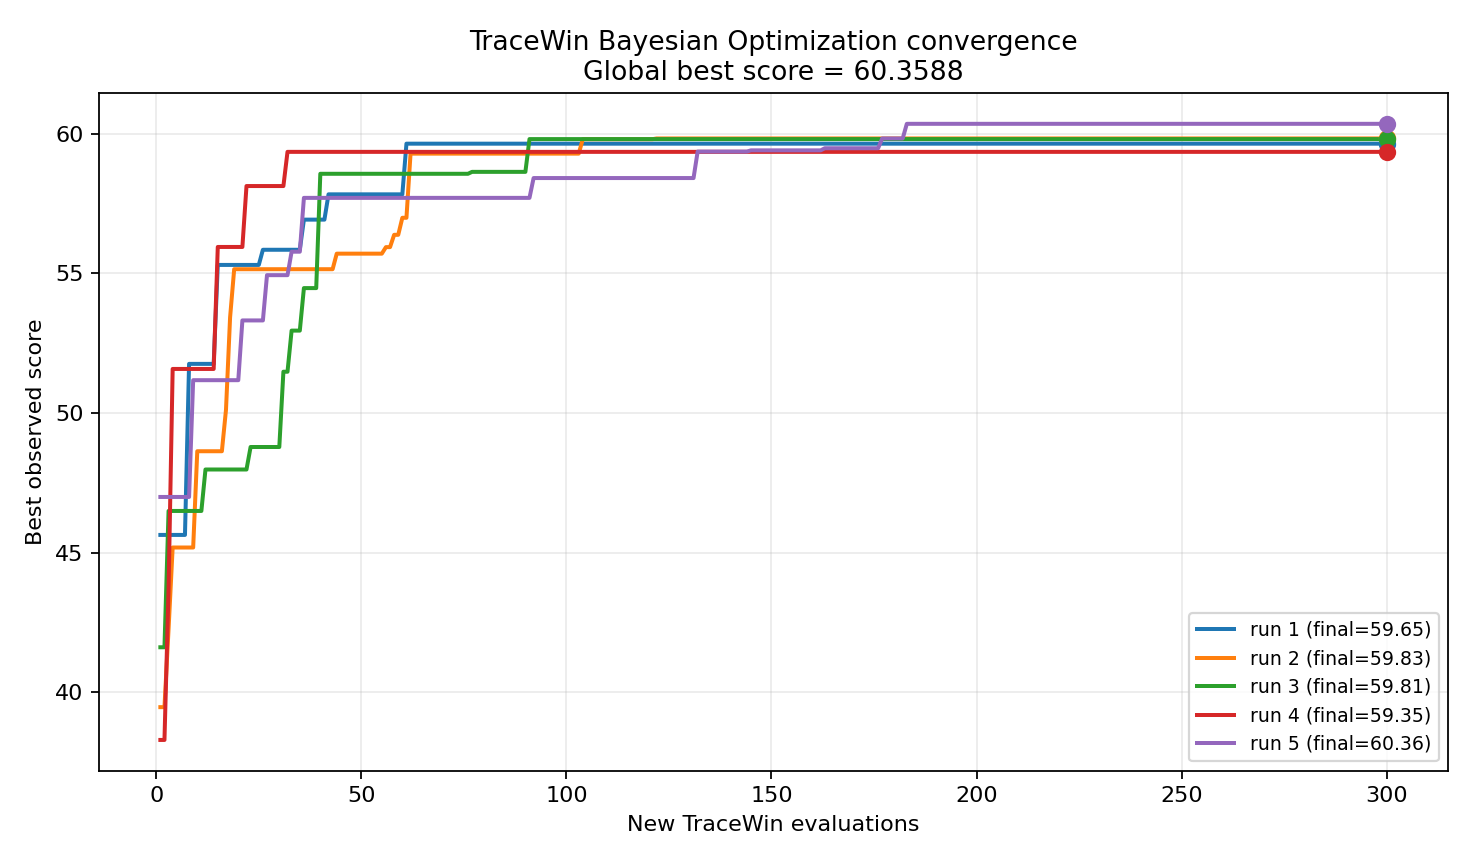

**Best-configuration shift from the nominal default**

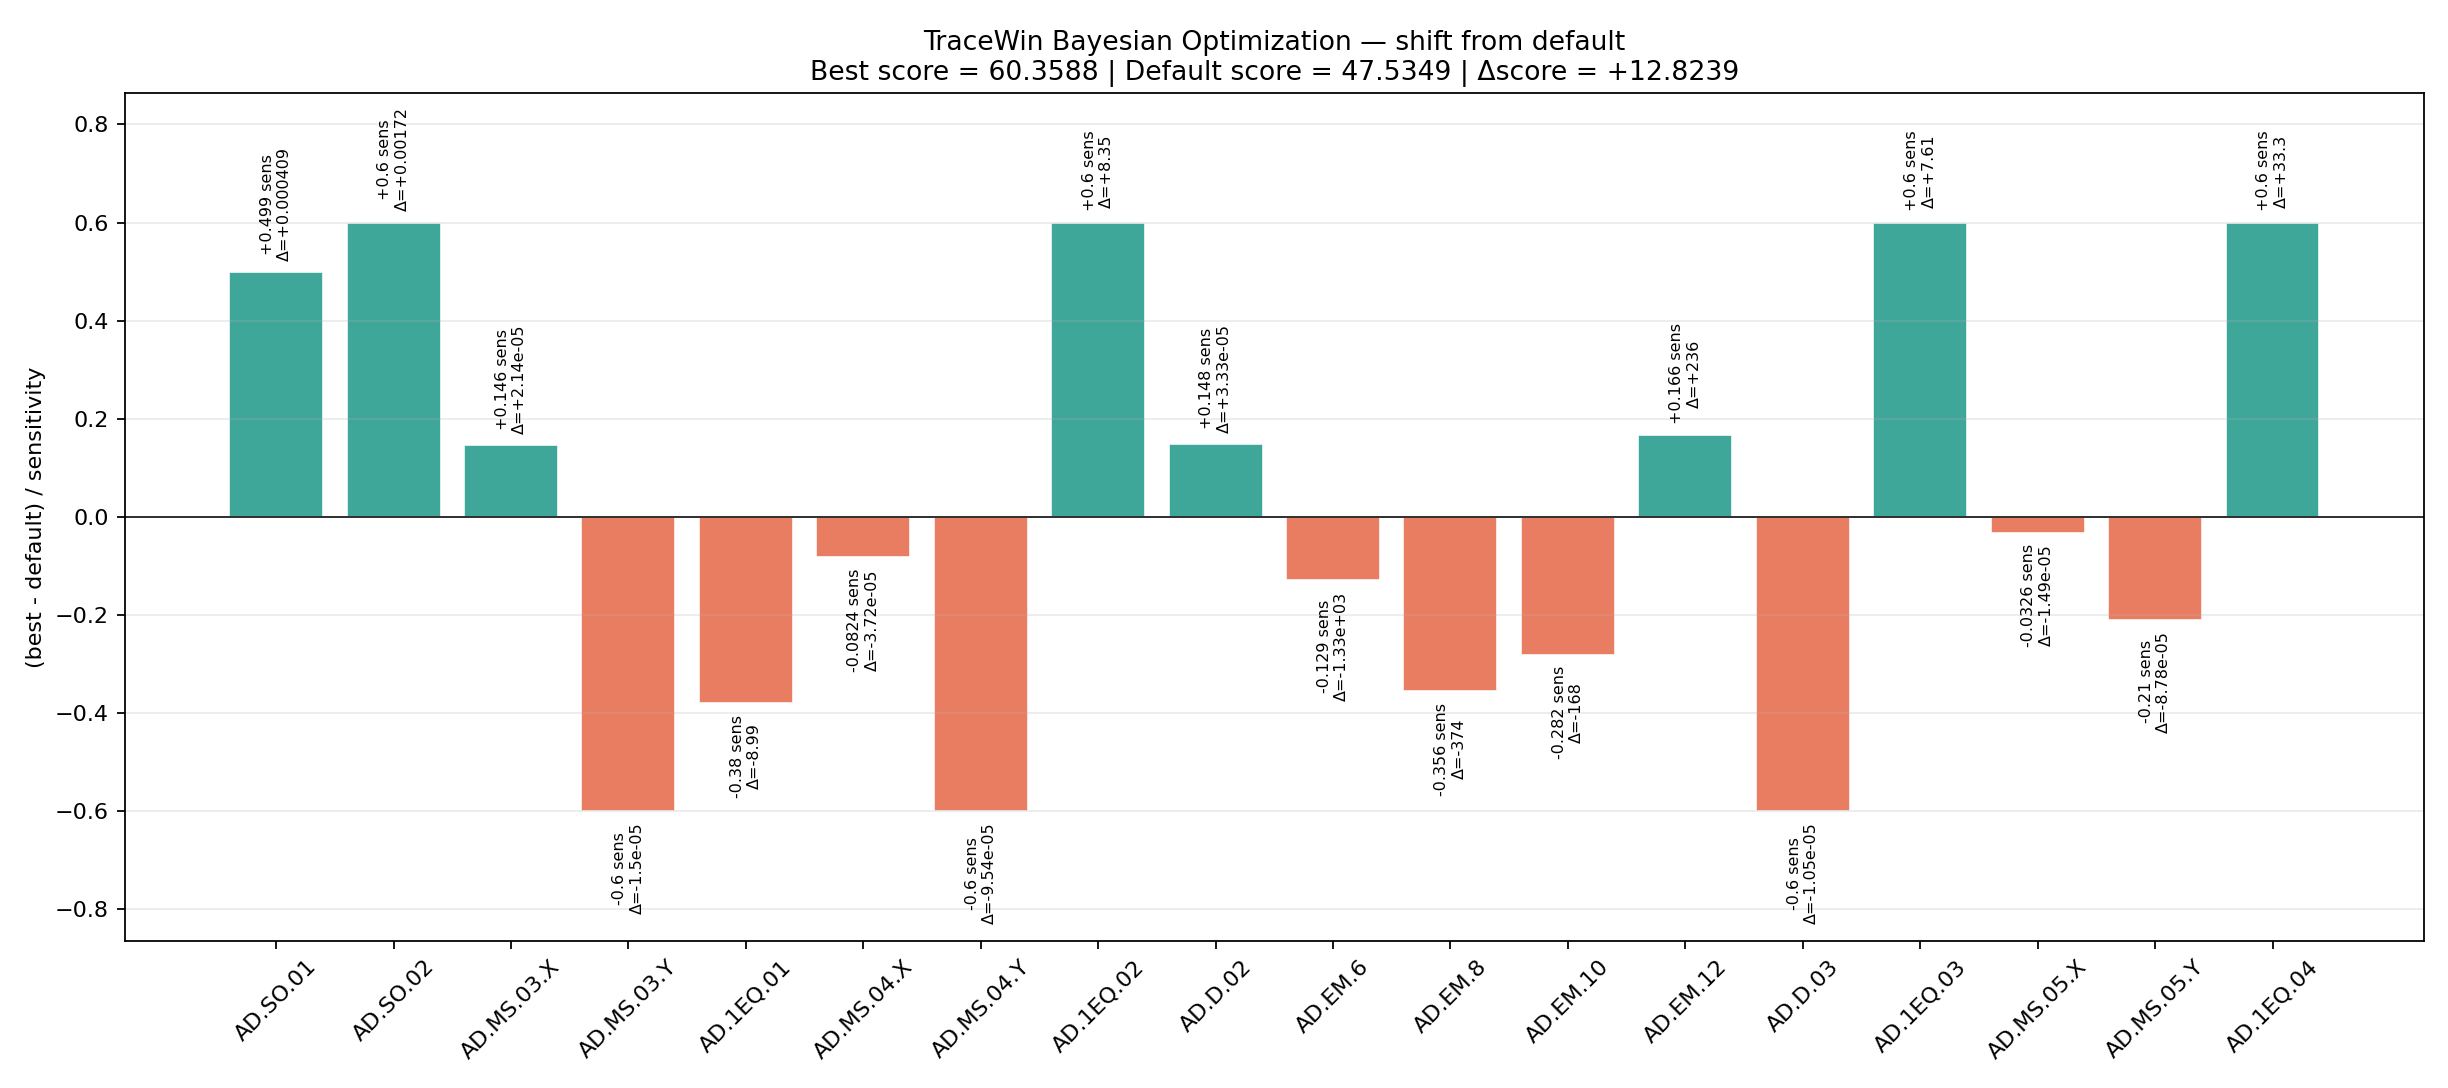

In [4]:
bayesian_report = json.loads((BAYESIAN_DIR / "results.json").read_text())
assert bayesian_report["score_function"]["sha256"] == benchmark_eval["score_function"]["sha256"]
bayesian_best = bayesian_report["best_result"]
bayesian_evaluations = [row for run in bayesian_report["runs"] for row in run["evaluations"]]

bayesian_summary = pd.DataFrame({"value": {
    "independent runs": len(bayesian_report["runs"]),
    "new evaluations per run": bayesian_report["config"]["n_calls"],
    "total new evaluations": len(bayesian_evaluations),
    "successful evaluations": sum(bool(row.get("success")) for row in bayesian_evaluations),
    "failed evaluations": sum(not bool(row.get("success")) for row in bayesian_evaluations),
    "warm-start points reused": len(bayesian_report.get("warm_start", [])),
    "best score": f"{bayesian_best['score']:.5f}",
    "best run": int(bayesian_best["run_index"]) + 1,
    "best call in run": int(bayesian_best["call_index"]) + 1,
}})
display(bayesian_summary)

display(Markdown("**Convergence by new TraceWin evaluations**"))
display(Image(filename=str(BAYESIAN_DIR / "bayesian_opt_convergence.png")))
display(Markdown("**Best-configuration shift from the nominal default**"))
display(Image(filename=str(BAYESIAN_DIR / "bayesian_opt_delta.png")))

## 4. Final decision

- SAC and TD3 sim-to-real are effectively tied in sustained final performance: SAC obtains
  59.50 ± 9.58 and TD3 59.30 ± 10.34, with zero failures for both.
- SAC is ahead by only 0.19 points on average and wins 12 of 20 matched resets; this benchmark
  does not provide evidence of a practically meaningful advantage between the two policies.
- TD3 records the highest configuration observed anywhere in these trajectories (70.96).
- Bayesian Optimization reaches 60.36 as a selected static optimum in a separate workspace-1
  campaign; that value is not directly equivalent to a policy mean across workspace-2 resets.

## 5. Timing: one Bayesian run vs one sim-to-real test episode

This final comparison considers the intended operations after policy selection:

- one complete Bayesian run: 300 TraceWin evaluations;
- one sim-to-real test episode: 20 environment steps, hence 20 TraceWin calls.

Bayesian durations are measured from saved timestamps. The policy-episode duration is estimated as
`20 × measured mean TraceWin-call time`, because the policy benchmark does not record timestamps.

**Measured Bayesian duration by run**

,TraceWin calls,duration min,average s/call,best score
run,,,,
1,300,134.7,27.0,59.65
2,300,124.3,24.9,59.83
3,300,119.0,23.9,59.81
4,300,112.8,22.6,59.35
5,300,117.2,23.5,60.36


**Direct operational comparison**

,TraceWin calls,duration min,basis
operation,,,
Sim-to-real policy: one 20-step test episode,20,8.1,estimated: 20 × mean call time
Bayesian Optimization: one complete run,300,121.6,measured mean across 5 runs


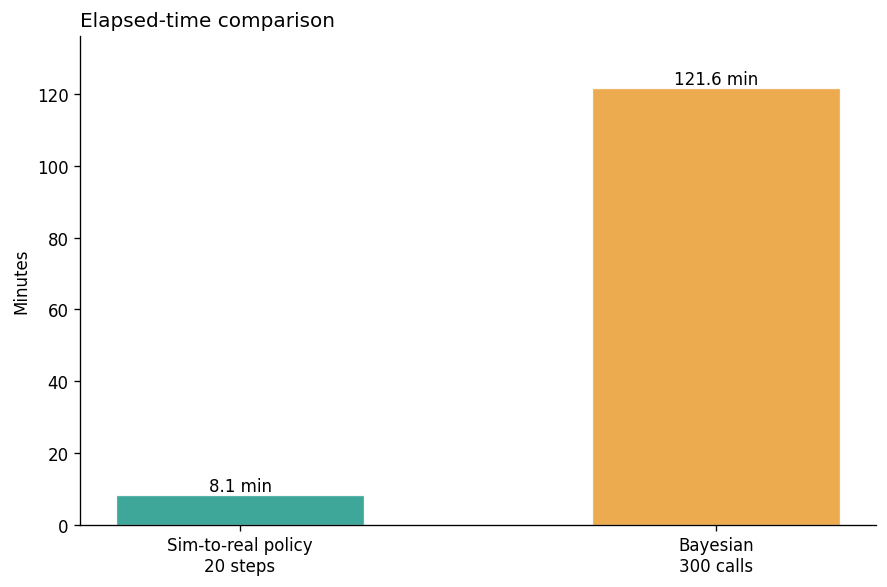

In [5]:
def parse_timestamp(value):
    return datetime.fromisoformat(value)


timing_rows = []
for run in bayesian_report["runs"]:
    timed = [row for row in run["evaluations"] if row.get("timestamp")]
    timestamps = [parse_timestamp(row["timestamp"]) for row in timed]
    duration_seconds = (max(timestamps) - min(timestamps)).total_seconds()
    timing_rows.append({
        "run": int(run["run_index"]) + 1,
        "TraceWin calls": len(timed),
        "duration min": duration_seconds / 60,
        "average s/call": duration_seconds / max(1, len(timed) - 1),
        "best score": run["best_score"],
    })

bayesian_timing = pd.DataFrame(timing_rows).set_index("run")
mean_call_seconds = (bayesian_timing["duration min"].sum() * 60
                     / (bayesian_timing["TraceWin calls"].sum() - len(bayesian_timing)))
mean_bayesian_run_minutes = bayesian_timing["duration min"].mean()
policy_episode_minutes = 20 * mean_call_seconds / 60

display(Markdown("**Measured Bayesian duration by run**"))
display(bayesian_timing.style.format({
    "duration min": "{:.1f}", "average s/call": "{:.1f}", "best score": "{:.2f}",
}))

timing_comparison = pd.DataFrame([
    {"operation": "Sim-to-real policy: one 20-step test episode", "TraceWin calls": 20,
     "duration min": policy_episode_minutes, "basis": "estimated: 20 × mean call time"},
    {"operation": "Bayesian Optimization: one complete run", "TraceWin calls": 300,
     "duration min": mean_bayesian_run_minutes, "basis": "measured mean across 5 runs"},
]).set_index("operation")
display(Markdown("**Direct operational comparison**"))
display(timing_comparison.style.format({"duration min": "{:.1f}"}))

fig, ax = plt.subplots(figsize=(7.5, 5.0))
labels = ["Sim-to-real policy\n20 steps", "Bayesian\n300 calls"]
values = [policy_episode_minutes, mean_bayesian_run_minutes]
ax.bar(
    labels,
    values,
    color=["#2A9D8F", "#E9A23B"],
    alpha=0.9,
    width=0.52,
    edgecolor="white",
    linewidth=0.8,
)
for index, value in enumerate(values):
    ax.text(index, value, f"{value:.1f} min", ha="center", va="bottom")
ax.set_title("Elapsed-time comparison", loc="left")
ax.set_ylabel("Minutes")
ax.set_ylim(0, max(values) * 1.12)
ax.grid(axis="y")
ax.grid(False, axis="x")
fig.tight_layout()
plt.show()

A TraceWin call takes **24.4 seconds on average** in the recorded Bayesian campaign. Therefore,
one sim-to-real episode is approximately **8.1 minutes**, while one complete Bayesian run takes **121.6
minutes on average**. The Bayesian run costs about **15 times more calls and wall-clock time** than
one deployment episode of the already selected policy. Policy training is excluded because it was
performed offline on the surrogate.